# Tracing Information in the Residual Stream

A transformer processes each token at every layer, maintaining a **residual stream** — a hidden state vector that accumulates information as it passes through attention and MLP blocks. Because any neural network is a causal model, we can ask mechanistic questions about it: *which layer and token position carries the information needed to produce the correct output?*

**Activation patching** (also called **interchange intervention**) answers this by isolating the contribution of individual residual stream cells. For a pair of inputs that differ in one variable, we patch the hidden state from the counterfactual into the original at each (layer, token_position) cell and observe whether the model's output flips. Cells that carry the distinguishing signal will cause a flip; cells that don't will leave the output unchanged.

In this notebook we:
1. Run a single-pair trace manually to build intuition about how information flows
2. Show how to scale this to a systematic analysis using the `locate` runner


In [1]:
# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1

from causalab.neural.pipeline import LMPipeline
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)
print("DEVICE:", pipeline.model.device)

`torch_dtype` is deprecated! Use `dtype` instead!
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


DEVICE: cuda:0


## Constructing a counterfactual pair

We use a simple MCQA task: the model is given a question with three answer choices labeled A, B, C and must output the correct label. The **causal variable** we want to trace is the label symbol attached to the correct answer.

Our counterfactual changes exactly that symbol — e.g., the correct answer is relabeled from `A` to `C` — so the two prompts differ in one position of the input text. We sample pairs until the model answers both correctly, ensuring we are tracing signal that actually matters to the model's prediction.


In [2]:
import random
from causalab.tasks.MCQA.causal_models import positional_causal_model
from causalab.tasks.MCQA.counterfactuals import sample_answerable_question

causal_model = positional_causal_model


def checker(neural_output, causal_output):
    return (
        causal_output.strip() in neural_output["string"].strip()
        or neural_output["string"].strip() in causal_output.strip()
    )


while True:
    original = sample_answerable_question()
    cf_inputs = {var: original[var] for var in causal_model.inputs}
    answer_symbol_key = f"symbol{original['answer_position']}"
    new_symbols = list({"A", "B", "C"}.difference({original[answer_symbol_key]}))
    cf_inputs[answer_symbol_key] = random.choice(new_symbols)
    counterfactual = causal_model.new_trace(cf_inputs)

    orig_pred = pipeline.generate([original]).strings[0]
    cf_pred = pipeline.generate([counterfactual]).strings[0]

    if checker({"string": orig_pred}, original["raw_output"]) and checker({"string": cf_pred}, counterfactual["raw_output"]):
        break

print("Original:")
print(f"  prompt:     {original['raw_input'].strip()}")
print(f"  prediction: {orig_pred.strip()!r}   expected: {original['raw_output'].strip()!r}")
print()
print("Counterfactual:")
print(f"  prompt:     {counterfactual['raw_input'].strip()}")
print(f"  prediction: {cf_pred.strip()!r}   expected: {counterfactual['raw_output'].strip()!r}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Original:
  prompt:     The flower is purple. What color is the flower?
N. purple
P. black
Answer:
  prediction: 'N'   expected: 'N'

Counterfactual:
  prompt:     The flower is purple. What color is the flower?
B. purple
P. black
Answer:
  prediction: 'B'   expected: 'B'


## Running the patching experiment

We now patch every (layer, token_position) cell in the residual stream. For each cell:
1. Run both prompts through the model, collecting the hidden state at that cell from the **counterfactual** run
2. Re-run the **original** prompt, replacing the hidden state at that cell with the collected counterfactual value
3. Record what the model outputs after this substitution

With `layers=None` we scan all layers, including the embedding layer (layer −1). This gives a complete picture of how the signal moves through the model.


In [ ]:
# PARAMETERS
LAYERS = None  # None = all layers including the embedding layer

from causalab.methods.interchange.single_pair import run_single_pair_trace
from causalab.neural.token_positions import get_list_of_each_token

token_positions = get_list_of_each_token(original["raw_input"], pipeline)
print(f"Token positions ({len(token_positions)}): {[tp.id for tp in token_positions]}")

result = run_single_pair_trace(
    pipeline=pipeline,
    prompt=original["raw_input"],
    counterfactual_prompt=counterfactual["raw_input"],
    token_positions=token_positions,
    layers=LAYERS,
    verbose=True,
)
print(f"\nCollected {len(result['intervention_results'])} intervention results")

## Visualizing the trace

The heatmap below places **layers on the y-axis** (earlier layers at top) and **token positions on the x-axis**. Each cell shows the model's output when that (layer, position) hidden state is replaced with the counterfactual value. Cells are colored by output frequency — tokens that appear often across cells get a consistent color, making patterns of signal flow visible at a glance.

We first serialize the raw intervention results into a `trace_data` dict, then pass it to the plotting function. This two-step pattern mirrors how `locate` saves the trace to disk before rendering — the same visualization call works whether the data comes from a live result or a saved artifact.


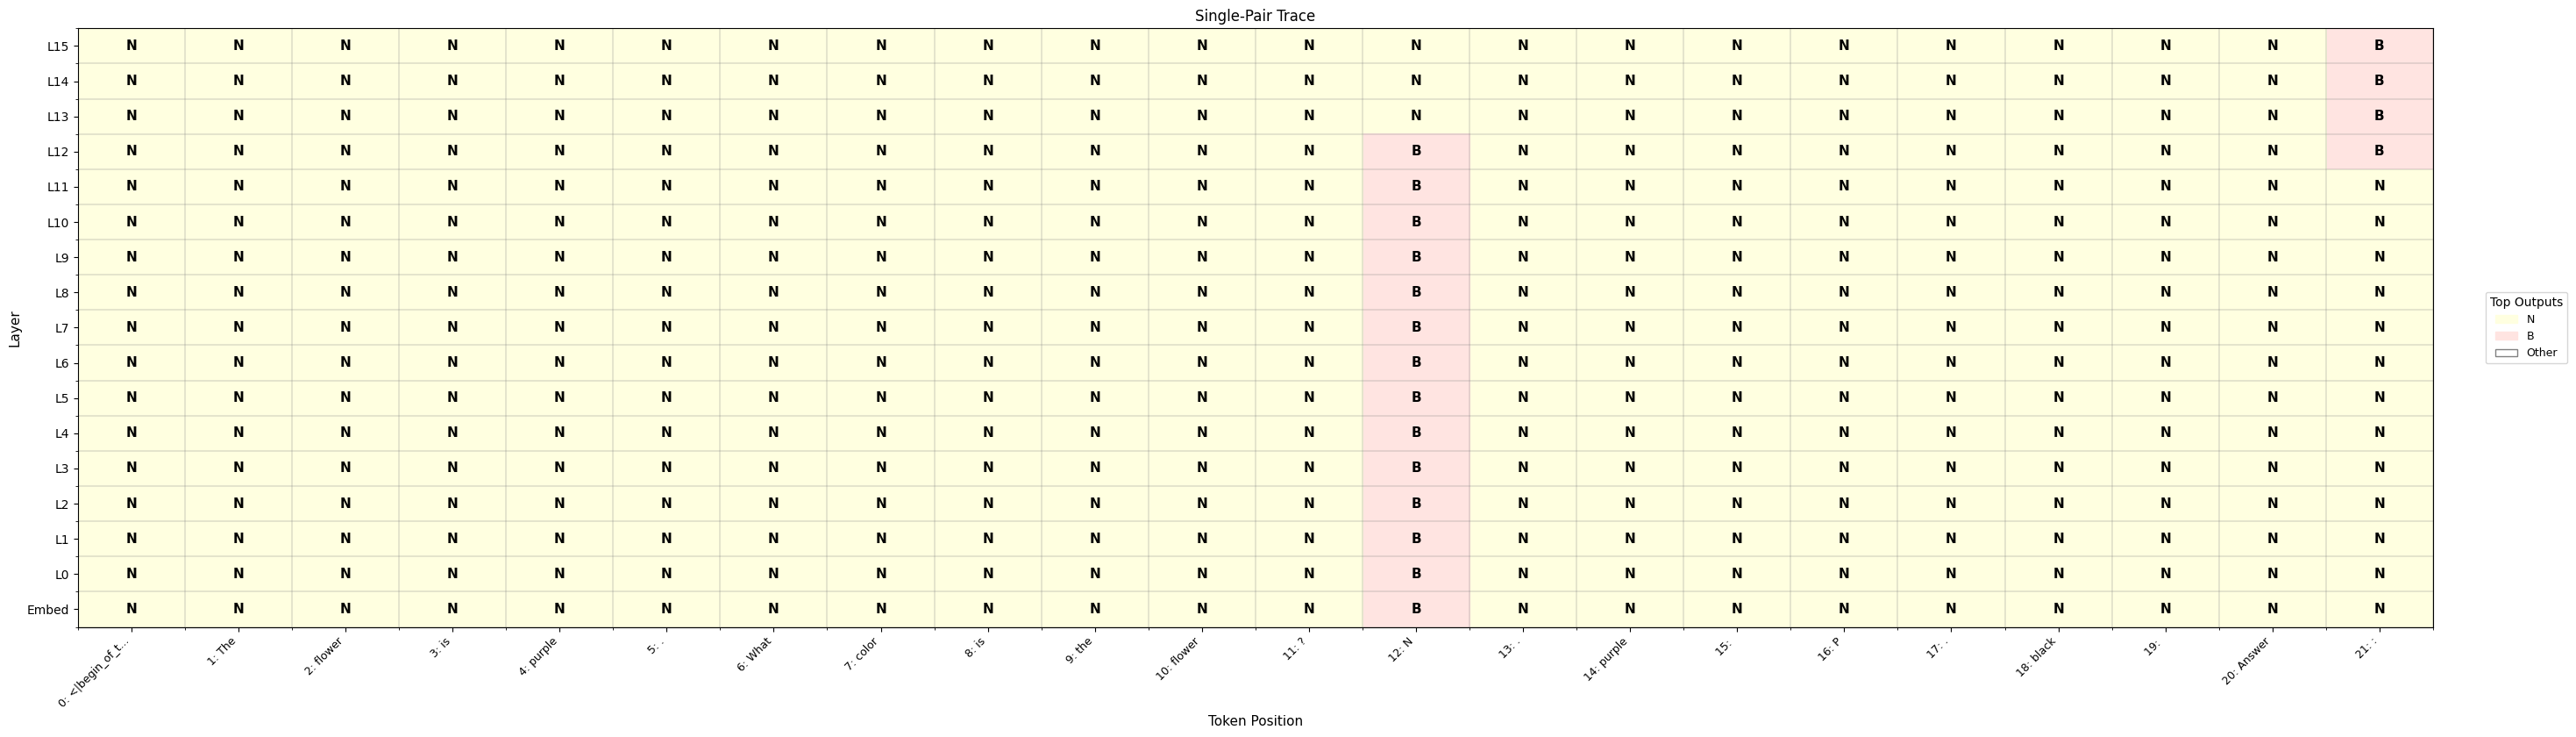

In [4]:
from causalab.io.plots.string_heatmap import build_token_labels, plot_single_pair_trace_heatmap

layers_used = result["metadata"]["layers_used"]
token_labels = build_token_labels(pipeline, original["raw_input"], token_positions)
token_position_ids = [tp.id for tp in token_positions]

cells = {}
for (layer, pos_id), res in result["intervention_results"].items():
    output_str = res.strings[0].strip() if res.strings else ""
    cells[f"{layer}|{pos_id}"] = {"output": output_str}

trace_data = {
    "prompt": original["raw_input"],
    "counterfactual_prompt": counterfactual["raw_input"],
    "layers": layers_used,
    "token_position_ids": token_position_ids,
    "token_labels": token_labels,
    "cells": cells,
}

plot_single_pair_trace_heatmap(trace_data, figure_format="png")

## What to look for

The trace reveals the model's routing strategy for this single input pair:

- **Embedding layer (first row)**: the signal is guaranteed to be at the answer symbol token — that is precisely where the two prompts differ at the embedding level.
- **Final layers (last rows)**: the signal is guaranteed to reach the last token position — that is where the unembedding head reads out the answer.
- **Middle layers**: the interesting part. Watch for the signal "hopping" from the answer symbol token column toward the last token column across layers. This hop is the model routing the variable from its input position to the output position via attention.

Rerun the cells above to sample a different input pair. The routing pattern is often consistent across examples, but varies enough to reward exploration.


---

## From exploration to analysis

The trace above answers a question about *one* input pair. A research question lives at the level of populations: **across all inputs, which (layer, token_position) cell most reliably encodes the causal variable?** Answering that requires:

- Repeating this experiment over many base/counterfactual pairs
- Aggregating the outputs into a single score per cell
- Running with a versioned, reproducible configuration
- Saving artifacts for downstream analyses (`subspace`, `activation_manifold`)

This is exactly what the **`locate` analysis** does. Under the hood it calls the same `run_single_pair_trace` and `plot_single_pair_trace_heatmap` you just wrote — packaged behind a Hydra config that becomes the single source of truth for every parameter. The rest of this notebook shows how to define that config and run `locate` end-to-end.

## Running `locate` end-to-end

The config below is a complete runner preset. Edit any field and re-run the cell to update the config file.

| Field | What it controls |
|---|---|
| `method` | `interchange` (activation patching) or `dbm_binary` (learned binary masks) |
| `mode` | `centroid` scores each cell by KL distance to per-class reference distributions; `pairwise` checks whether patching causes the model to output the counterfactual's exact answer |
| `layers` | Which layers to scan; `null` scans all |
| `n_steer` | Number of examples per class used to compute class centroids (centroid mode) |
| `enumerate_all` | Set to `true` to use every possible input rather than sampling |


In [ ]:
config_yaml = """\
# @package _global_
defaults:
  - /base
  - /task: MCQA
  - /model: llama32_1b_instruct
  - /analysis/locate
  - _self_
task:
  enumerate_all: true  # use all possible MCQA inputs
  target_variables: [answer]

locate:
  method: interchange
  mode: centroid  # centroid works correctly with resample_variable: all
  layers: [0, 4, 8, 12, 15]
  n_steer: 32
  visualization:
    figure_format: png
"""

In [6]:
from omegaconf import OmegaConf
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "residual_stream_tracing_demo")
print(f"Written to {path}\n")

cfg = load_runner_config("residual_stream_tracing_demo")
print("Full hydra config:")
print(OmegaConf.to_yaml(cfg))

Written to causalab/runner/configs/runner/residual_stream_tracing_demo.yaml

Full hydra config:
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variables:
  - answer
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
seed: 42
code_trace: false
experiment_root: artifacts/${task.name}/${model.id}
locate:
  _name_: locate
  _subdir: ${.method}
  _output_dir: ${experiment_root}/locate/${._subdir}
  method: interchange
  batch_size: 32
  layers:
  - 0
  - 4
  - 8
  - 12
  - 15
  token_positions: null
  component: residual_stream
  mode: centroid
  n_steer: 32
  source_model: null
  visualization:
    figure_format: png
    single_pair_trace: true



Run the analysis via `scripts/run_exp.sh`. This is the same entry point used from the command line.


In [7]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "residual_stream_tracing_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-04-21 11:33:53,501][__main__][INFO] - === Step: locate (locate) ===
[2026-04-21 11:34:05,742][causalab.io.pipelines][INFO] - Loading model: meta-llama/Llama-3.2-1B-Instruct (device=cuda)


`torch_dtype` is deprecated! Use `dtype` instead!
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-04-21 11:34:06,628][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'
[2026-04-21 11:34:07,362][causalab.analyses.locate.main][INFO] - Locate scan over variables: ['answer']
[2026-04-21 11:34:07,363][causalab.analyses.locate.main][INFO] - === Locate: target_variable=answer ===
[2026-04-21 11:34:07,733][causalab.runner.helpers][INFO] - Deduplicated train: 1000 -> 999 unique prompts
[2026-04-21 11:34:07,745][causalab.runner.helpers][INFO] - Dataset: 999 train, 50 test
[2026-04-21 11:34:07,748][causalab.analyses.locate.run_interchange][WARNING] - No baseline accuracy found at artifacts/MCQA/llama32_1b_instruct/baseline/accuracy.json
[2026-04-21 11:34:07,748][causalab.analyses.locate.run_interchange][WARNING] - No baseline ref_dists found at 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


[2026-04-21 11:34:08,628][causalab.methods.metric][INFO] - Base model accuracy: 49/50 (98.0%)
[2026-04-21 11:34:08,629][causalab.methods.metric][INFO] - Base model prob accuracy: 74.9%


Centroid layer scan: 100%|██████████| 35/35 [00:38<00:00,  1.10s/it]


Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Plast_token/patched_dim0.png
[2026-04-21 11:34:53,436][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Plast_token/patched_dim0.png
Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol/patched_dim0.png
[2026-04-21 11:34:53,755][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol/patched_dim0.png
Saved figure to artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol_period/patched_dim0.png
[2026-04-21 11:34:54,099][causalab.analyses.path_steering.path_visualization][INFO] - Saved ground truth line plot: artifacts/MCQA/llama32_1b_instruct/locate/interchange/answer/L0/Pcorrect_symbol_period/patched_dim0.png
Saved figure to 

## Artifacts

All outputs land in `artifacts/{task}/{model}/locate/{method}/`.


In [8]:
artifact_dir = os.path.join(
    project_root, cfg.experiment_root, "locate", cfg.locate.method,
)
print(f"Artifact directory: {artifact_dir}\n")
print("Contents:", sorted(os.listdir(artifact_dir)))

Artifact directory: artifacts/MCQA/llama32_1b_instruct/locate/interchange

Contents: ['answer', 'metadata.json', 'results.json', 'single_pair_trace.json', 'single_pair_trace_heatmap.png']


### Single-pair trace

The `single_pair_trace.json` artifact is exactly the `trace_data` dict you built above — now saved to disk by the analysis. Loading it and calling `plot_single_pair_trace_heatmap` is identical to what you did in Section 1.


Base:           The ball is purple. What color is the ball?
E. purple
X. yellow
Answer:
Counterfactual: The ball is purple. What color is the ball?
D. purple
W. yellow
Answer:



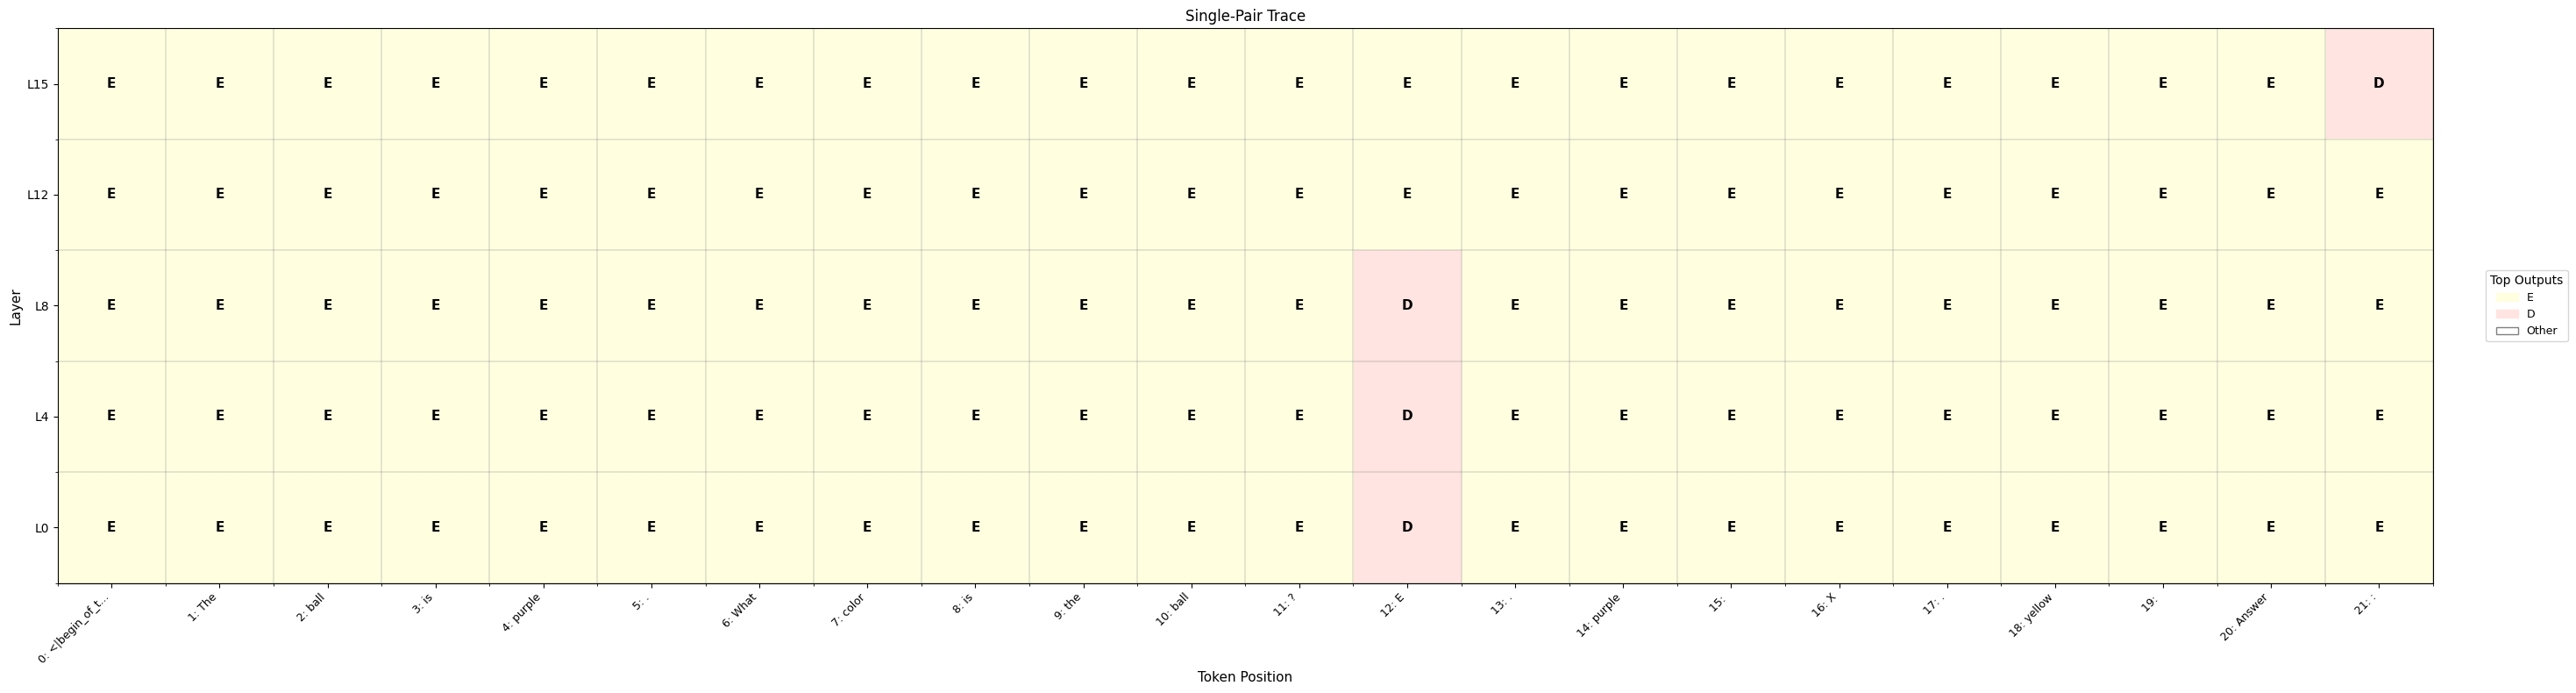

In [9]:
import json
from causalab.io.plots.string_heatmap import plot_single_pair_trace_heatmap

trace_path = os.path.join(artifact_dir, "single_pair_trace.json")
with open(trace_path) as f:
    saved_trace_data = json.load(f)

print(f"Base:           {saved_trace_data['prompt']}")
print(f"Counterfactual: {saved_trace_data['counterfactual_prompt']}")
print()

plot_single_pair_trace_heatmap(saved_trace_data, figure_format="png")

### Score heatmap

Unlike the single-pair trace which shows raw string outputs, the score heatmap aggregates over many examples. Each cell's score is the fraction of classes whose patched distribution is closer to the correct ground-truth reference than to any other class. A score of 1.0 means patching at that cell perfectly recovers the causal variable; chance-level is 1/n_classes.

The heatmap identifies the best (layer, token_position) site for each target variable — the input to downstream analyses.



--- answer ---


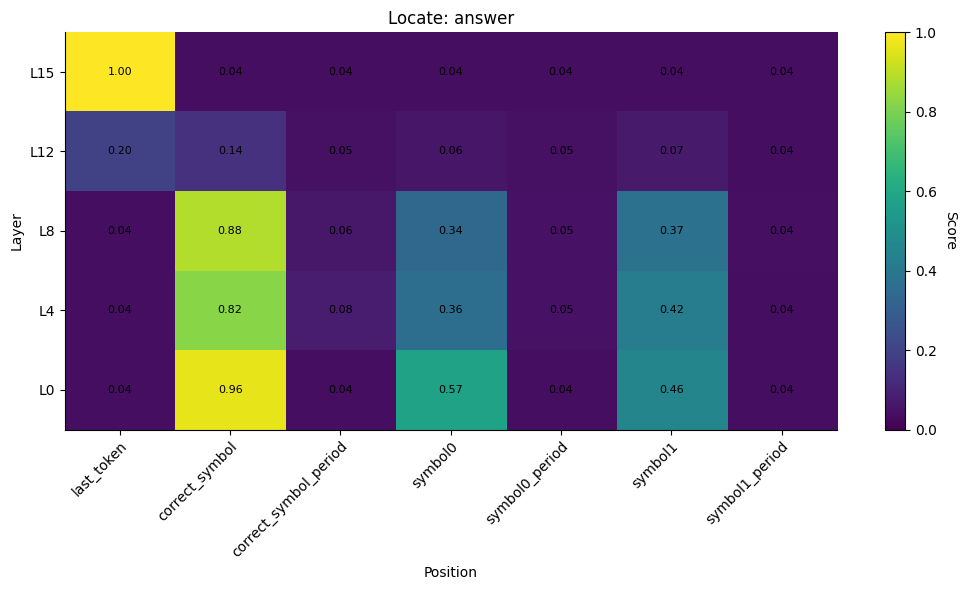

In [10]:
from glob import glob
from IPython.display import Image, display

for var_name in sorted(os.listdir(artifact_dir)):
    var_dir = os.path.join(artifact_dir, var_name)
    if not os.path.isdir(var_dir):
        continue
    matches = glob(os.path.join(var_dir, "heatmap.png"))
    if matches:
        print(f"\n--- {var_name} ---")
        display(Image(filename=matches[0]))

## Takeaway

The single-pair trace gives intuition about one example; the score heatmap quantifies localization across the full dataset. Together they answer the first mechanistic question in the pipeline: **where** does the model encode a given causal variable?

When the heatmap shows a clear localized cell (one dark region, not uniform noise), the `results.json` artifact records the best (layer, position) which downstream analyses auto-resolve when no explicit layer is passed.

**What comes next:**
- `subspace` — find the low-dimensional linear directions that encode the variable within the best cell's activation space
- `activation_manifold` — map the geometric structure of how the variable is represented

For the full `locate` walkthrough including centroid vs pairwise mode, DBM binary masks, and multi-variable scans: `causalab/analyses/locate/demo.ipynb`.
